# Case Study Insights: Deep Learning for Time Series

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of temporal deep learning
(LSTM, NLinear, TSMixer, TCN, PatchTST) and contrast it with the linear
baseline (Ch11), gradient boosting (Ch12), and the tabular DL adapter TabM
(Ch12). Per-case-study deep dives live in `case_studies/{cs}/11_model_analysis.py`;
this notebook is the comparative view across the eight case studies that carry
DL pipelines.

**Learning objectives**

- For each case study, read the highest-IC DL configuration's average daily
  Spearman IC with HAC 95 % CI on the primary label
- Trace the architecture × case-study coverage map and the per-architecture
  IC at the primary label
- Inspect per-fold IC distributions, checkpoint dynamics, and conformal
  coverage at the 90 % nominal level
- Compare full-coverage DL and tabular daily-IC point estimates without
  treating fold summaries as an uncertainty estimator
- Place the DL family inside the architectural-class taxonomy (recurrent,
  MLP-style, convolutional, attention)

**Book reference**: Section 13.7 (Practitioner Framework) and Section 13.9
(Cross-Case-Study Synthesis).

**Prerequisites**: each case study's per-architecture training notebooks
(`dl_lstm.py`, `dl_nlinear.py`, `dl_tsmixer.py`, `dl_tcn.py`, `dl_patchtst.py`)
have populated `run_log/registry.db` for the `deep_learning` family. The
linear, GBM, and TabM baselines come from Ch11-Ch12 pipelines.

In [1]:
"""Case Study Insights: Deep Learning cross-case-study registry aggregation."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

In [2]:
# The registry helpers enforce exact snapshot identity, complete day/fold
# coverage, and exact artifact lineage before comparisons are assembled.
from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    DATASET_META,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_complete_checkpoint_fold_trajectories,
    collect_complete_fold_ic_per_cs,
    collect_complete_grid_per_cs,
    collect_complete_multi_label_per_cs,
    collect_complete_rank1_per_cs,
    conformal_coverage_for_selected_prediction,
    plot_cross_cs_forest,
    plot_multi_label_horizon,
    plot_per_fold_violin,
    require_registry_sha256,
)
from case_studies.utils.model_analysis import (
    load_metrics_from_registry,
)
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette

warnings.filterwarnings("ignore")

In [3]:
SEED = 42
FAMILY = "deep_learning"
TABULAR_BASELINES = ("linear", "gbm", "tabular_dl")
CONFORMAL_LEVEL = 0.90
REGISTRY_SNAPSHOT = "2026-07-22-v3.1-map-r3"
REGISTRY_MAP_SHA256 = "9bb3fd027d12a650cda72ac09773bb0985d638a59c457c3c08680a0c3d22c909"
REGISTRY_SHA256_PINS = {
    "etfs": "771c02b3db7047b9c6e25c60c18d8b3b02dfc4ade2cb6b791b40f6b410f29509",
    "crypto_perps_funding": "c7c1e67f8fe4476d7631061e61ce89de1a521606a7c0ff807ba1dcdad23fc485",
    "nasdaq100_microstructure": "9154d213dd1020fbeb2f64213a82bb8b44b8c20d4ed14db842ab735b2b275bd0",
    "sp500_equity_option_analytics": "953e580467ae704a6b05e6fbbd03599bf799eb6ac084455d8a4bdcb8dcf62164",
    "us_firm_characteristics": "d50310f512ce0c95edbb9b0c31ae0501a4b0246c0618a02bab4ba6e7fd80015d",
    "fx_pairs": "1d0e4ef26766ef6857c562438fb3eced253111ae3fe3777895af98cc79ce8f9d",
    "cme_futures": "58b408c9e9ec008606c04b8bc68b0ef3865c9f14b7ba064af2b378adb45794dc",
    "sp500_options": "395ed2debf0ad736a9736c3936cbfc1a9dd28cc54eb23acfb97c8017c094958a",
    "us_equities_panel": "3175eca6747ebc5e3fc886576e94aef755de9e8a8eeb16d3d967f7f74793a39e",
}
REGISTRY_VERSION_STATUS = {
    "cme_futures": "accepted_sdf_temporal_corrected",
    "crypto_perps_funding": "accepted",
    "etfs": "accepted_pre_ipca",
    "fx_pairs": "accepted",
    "nasdaq100_microstructure": "provisional_snapshot_20260722T182456",
    "sp500_equity_option_analytics": "accepted_v3.1_garch_corrected",
    "sp500_options": "accepted_current_r8_gpu",
    "us_equities_panel": "provisional_snapshot_20260720T222537",
    "us_firm_characteristics": "accepted",
}
REGISTRY_FOREIGN_KEY_DEBT: dict[str, int] = {}

In [4]:
set_global_seeds(SEED)

In [5]:
registry_rows = []
for cs in CASE_STUDY_IDS:
    expected = REGISTRY_SHA256_PINS[cs]
    observed = require_registry_sha256(cs, expected)
    registry_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "registry_snapshot": REGISTRY_SNAPSHOT,
            "registry_map_sha256": REGISTRY_MAP_SHA256,
            "registry_sha256": observed,
            "publication_status": REGISTRY_VERSION_STATUS[cs],
            "foreign_key_violations": REGISTRY_FOREIGN_KEY_DEBT.get(cs, 0),
        }
    )
registry_provenance = pl.DataFrame(registry_rows)
print("Read-only provenance for the pinned teaching registry map:")
registry_provenance

Read-only provenance for the pinned teaching registry map:


case_study,registry_snapshot,registry_map_sha256,registry_sha256,publication_status,foreign_key_violations
str,str,str,str,str,i64
"""ETFs""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""771c02b3db7047b9c6e25c60c18d8b…","""accepted_pre_ipca""",0
"""Crypto""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""c7c1e67f8fe4476d7631061e61ce89…","""accepted""",0
"""NQ100""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""9154d213dd1020fbeb2f64213a82bb…","""provisional_snapshot_20260722T…",0
"""SP500 Eq+Opt""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""953e580467ae704a6b05e6fbbd0359…","""accepted_v3.1_garch_corrected""",0
"""US Firms""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""d50310f512ce0c95edbb9b0c31ae05…","""accepted""",0
"""FX""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""1d0e4ef26766ef6857c562438fb3ec…","""accepted""",0
"""CME Futures""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""58b408c9e9ec008606c04b8bc68b0e…","""accepted_sdf_temporal_correcte…",0
"""SP500 Options""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""395ed2debf0ad736a9736c3936cbfc…","""accepted_current_r8_gpu""",0
"""US Equities""","""2026-07-22-v3.1-map-r3""","""9bb3fd027d12a650cda72ac09773bb…","""3175eca6747ebc5e3fc886576e94ae…","""provisional_snapshot_20260720T…",0


**Architecture helper**: maps registry `config_name` values to the display
names used across every downstream table and figure so the four LSTM
variants collapse to a single `LSTM` row and the per-architecture grids
stay consistent.

In [6]:
def architecture(config_name: str) -> str:
    """Display name for a DL config_name (LSTM variants collapse to 'LSTM')."""
    if config_name.startswith("lstm"):
        return "LSTM"
    return {"nlinear": "NLinear", "tsmixer": "TSMixer", "tcn": "TCN", "patchtst": "PatchTST"}.get(
        config_name,
        config_name.upper(),
    )

Architectural classes support the aggregate comparison, while the complete
grid loader keeps missing architectures explicit.

In [7]:
ARCH_CLASS = {
    "LSTM": "recurrent",
    "NLinear": "MLP-style",
    "TSMixer": "MLP-style",
    "TCN": "convolutional",
    "PatchTST": "attention",
}

dl_grid = collect_complete_grid_per_cs(
    CASE_STUDY_IDS,
    FAMILY,
    approved_registry_sha256=REGISTRY_SHA256_PINS,
    allow_missing=True,
)

## 1. Scope and Coverage

The DL grid varies across the case studies - not every architecture trains
on every panel, and US Firm Characteristics (monthly cross-section) carries
no DL family at all. The headline metric is the average daily Spearman IC
with HAC 95 % confidence interval on each case study's primary label
(`prediction_metrics.ic_mean_daily`, `ic_ci_lo`, `ic_ci_hi`, `ic_t_hac`).
The linear (Ch11), GBM (Ch12), and TabM (`tabular_dl`, Ch12) baselines are
loaded so the §5 delta is computable.

In [8]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    dl = dl_grid.filter(pl.col("case_study") == cs)
    if dl.is_empty():
        coverage_rows.append(
            {
                "case_study": SHORT_NAMES[cs],
                "primary_label": primary,
                "dl_archs": "-",
                "n_dl_configs": 0,
            }
        )
        continue
    archs = sorted({architecture(c) for c in dl["config_name"].unique().to_list()})
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "dl_archs": ", ".join(archs),
            "n_dl_configs": dl["config_name"].n_unique(),
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("DL architecture coverage per case study (primary label):")
coverage_df

DL architecture coverage per case study (primary label):


case_study,primary_label,dl_archs,n_dl_configs
str,str,str,i64
"""ETFs""","""fwd_ret_21d""","""LSTM, TSMixer""",2
"""Crypto""","""fwd_ret_8h""","""LSTM, NLinear, TCN""",3
"""NQ100""","""fwd_ret_15m""","""LSTM, NLinear, PatchTST, TCN""",4
"""SP500 Eq+Opt""","""fwd_ret_5d""","""LSTM, NLinear, PatchTST""",3
"""US Firms""","""fwd_ret_1m""","""-""",0
"""FX""","""fwd_ret_1d""","""LSTM, NLinear, TCN""",3
"""CME Futures""","""fwd_ret_5d""","""LSTM, NLinear""",2
"""SP500 Options""","""ret_to_expiry""","""LSTM, PatchTST""",2
"""US Equities""","""fwd_ret_1d""","""LSTM, NLinear, TSMixer""",3


In [9]:
# Architecture × CS availability matrix at the primary label
all_archs_sorted = ["LSTM", "NLinear", "TSMixer", "TCN", "PatchTST"]
avail_rows = []
for cs in CASE_STUDY_IDS:
    dl = dl_grid.filter(pl.col("case_study") == cs)
    if dl.is_empty():
        for arch in all_archs_sorted:
            avail_rows.append({"short_name": SHORT_NAMES[cs], "architecture": arch, "ic": None})
        continue
    by_arch = (
        dl.with_columns(
            architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8)
        )
        .group_by("architecture")
        .agg(pl.col("ic_mean_daily").max().alias("ic"))
    )
    arch_to_ic = dict(by_arch.iter_rows())
    for arch in all_archs_sorted:
        avail_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "architecture": arch,
                "ic": arch_to_ic.get(arch),
            }
        )

avail_df = pl.DataFrame(avail_rows)
avail_pivot = avail_df.pivot(index="short_name", on="architecture", values="ic").sort("short_name")
print(
    "Highest-IC DL configuration per (case study × architecture) at the primary label "
    "(blank = architecture not trained on this case study):"
)
avail_pivot.select(["short_name", *all_archs_sorted])

Highest-IC DL configuration per (case study × architecture) at the primary label (blank = architecture not trained on this case study):


short_name,LSTM,NLinear,TSMixer,TCN,PatchTST
str,f64,f64,f64,f64,f64
"""CME Futures""",0.00396,-0.008415,null,null,null
"""Crypto""",0.005066,0.029333,null,0.002422,null
"""ETFs""",0.006047,null,0.019672,null,null
"""FX""",0.002288,0.010566,null,0.009935,null
"""NQ100""",0.00346,0.00456,null,0.000419,0.001656
"""SP500 Eq+Opt""",0.009961,0.010526,null,null,0.007365
"""SP500 Options""",0.013843,null,null,null,0.009017
"""US Equities""",0.006584,0.005825,0.003269,null,null
"""US Firms""",null,null,null,null,null


Architecture coverage is computed from full-day, exact-fold candidates. A
missing family stays missing rather than being filled with a shorter-span or
stale candidate.

In [10]:
architecture_coverage = (
    dl_grid.with_columns(
        architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8)
    )
    .group_by("architecture")
    .agg(n_case_studies=pl.col("case_study").n_unique())
    .sort("n_case_studies", descending=True)
)
missing_dl = [
    SHORT_NAMES[cs] for cs in CASE_STUDY_IDS if cs not in set(dl_grid["case_study"].to_list())
]
display(
    Markdown(
        f"**Computed coverage ({REGISTRY_SNAPSHOT}).** "
        f"{dl_grid['case_study'].n_unique()} of {len(CASE_STUDY_IDS)} case studies have a "
        f"complete DL candidate; missing: {', '.join(missing_dl) or 'none'}."
    )
)
architecture_coverage

**Computed coverage (2026-07-22-v3.1-map-r3).** 8 of 9 case studies have a complete DL candidate; missing: US Firms.

architecture,n_case_studies
str,u32
"""LSTM""",8
"""NLinear""",6
"""TCN""",3
"""PatchTST""",3
"""TSMixer""",2


## 2. Cross-CS Forest of Highest-IC DL Configurations

For each DL-covered case study, the architecture and configuration with
the highest average daily IC on the primary label is plotted with its HAC
95 % CI. Filled markers indicate $|t_{HAC}| > 2$ (CI excludes zero); open
markers indicate the CI overlaps zero.

In [11]:
dl_rank1 = collect_complete_rank1_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
    approved_registry_sha256=REGISTRY_SHA256_PINS,
    allow_missing=True,
)
dl_rank1_display = dl_rank1.with_columns(
    architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8),
)
print("Highest-IC DL configuration per case study (primary label, average daily IC ± HAC 95 % CI):")
dl_rank1_display.select(
    "short_name",
    "label",
    "architecture",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC DL configuration per case study (primary label, average daily IC ± HAC 95 % CI):


short_name,label,architecture,config_name,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,str,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""TSMixer""","""tsmixer""",0.0197,-0.0124,0.0517,1.2,2016
"""Crypto""","""fwd_ret_8h""","""NLinear""","""nlinear""",0.0293,0.0168,0.0419,4.58,1956
"""NQ100""","""fwd_ret_15m""","""NLinear""","""nlinear""",0.0046,0.0007,0.0084,2.32,64580
"""SP500 Eq+Opt""","""fwd_ret_5d""","""NLinear""","""nlinear""",0.0105,-0.0102,0.0313,1.0,497
"""FX""","""fwd_ret_1d""","""NLinear""","""nlinear""",0.0106,-0.0049,0.026,1.34,2064
"""CME Futures""","""fwd_ret_5d""","""LSTM""","""lstm_h64""",0.004,-0.0212,0.0291,0.31,1290
"""SP500 Options""","""ret_to_expiry""","""LSTM""","""lstm_h64""",0.0138,-0.0089,0.0366,1.19,484
"""US Equities""","""fwd_ret_1d""","""LSTM""","""lstm_h64""",0.0066,0.0042,0.009,5.37,4018


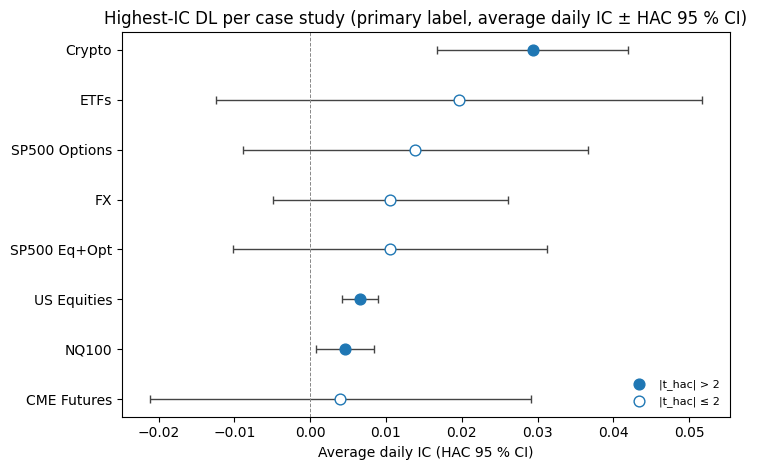

In [12]:
fig, forest_ax = plot_cross_cs_forest(
    dl_rank1,
    family=FAMILY,
    title="Highest-IC DL per case study (primary label, average daily IC ± HAC 95 % CI)",
)
forest_ax.set_xlabel("Average daily IC (HAC 95 % CI)")
fig.show()

In [13]:
n_dl_total = dl_rank1.height
n_sig = int((dl_rank1["ic_t_hac"].abs() > 2.0).sum())
print(f"DL CI excludes zero ({{|t_HAC|>2}}) on {n_sig} of {n_dl_total} DL-covered case studies.")

DL CI excludes zero ({|t_HAC|>2}) on 3 of 8 DL-covered case studies.


In [14]:
dl_clear_names = dl_rank1.filter(pl.col("ic_t_hac").abs() > 2)["short_name"].to_list()
dl_overlap_names = dl_rank1.filter(pl.col("ic_t_hac").abs() <= 2)["short_name"].to_list()
display(
    Markdown(
        f"**Computed DL inference.** The HAC interval excludes zero for {len(dl_clear_names)} "
        f"of {dl_rank1.height} selected rows ({', '.join(dl_clear_names) or 'none'}) and "
        f"overlaps zero for {', '.join(dl_overlap_names) or 'none'}."
    )
)

**Computed DL inference.** The HAC interval excludes zero for 3 of 8 selected rows (Crypto, NQ100, US Equities) and overlaps zero for ETFs, SP500 Eq+Opt, FX, CME Futures, SP500 Options.

## 3. Within-Family Comparison

Three subsections trace the architecture grid: the highest IC by architecture
inside each case study (3a), the aggregate count of which architecture
achieves the highest IC (3b), and the per-checkpoint IC trajectory of the
highest-IC configuration on each case study (3c).

### 3a. Architecture × case-study heatmap

Within each case study, the highest IC achieved by each architecture is
shown as a heatmap cell. Cells are blank where the architecture was not
trained on that case study - coverage gaps remain visible.

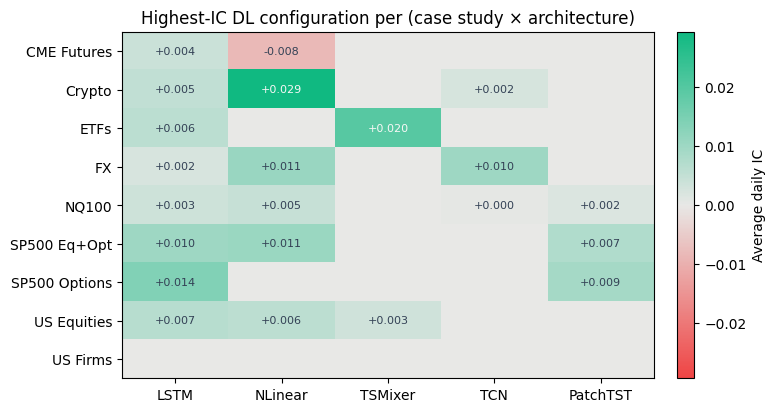

In [15]:
arch_cols = all_archs_sorted
cs_labels = avail_pivot["short_name"].to_list()
matrix_values = avail_pivot.select(arch_cols).to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
finite_vals = matrix_values[np.isfinite(matrix_values.astype(float))]
vmax = float(np.nanmax(np.abs(finite_vals))) if finite_vals.size else 0.05
masked = np.ma.array(matrix_values.astype(float), mask=~np.isfinite(matrix_values.astype(float)))
cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
cmap.set_bad(color=COLORS["silver_muted"])
im = ax.imshow(masked, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(arch_cols)))
ax.set_xticklabels(arch_cols)
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(arch_cols)):
        v = matrix_values[i, j]
        if v is not None and np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=COLORS["silver"] if abs(v) > 0.6 * vmax else COLORS["neutral"],
            )
        else:
            ax.text(j, i, "-", ha="center", va="center", fontsize=8, color=COLORS["silver_muted"])
ax.set_title("Highest-IC DL configuration per (case study × architecture)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Average daily IC")
fig.show()

In [16]:
winner_text = ", ".join(
    f"{row['short_name']}: {row['architecture']}"
    for row in dl_rank1_display.sort("short_name").iter_rows(named=True)
)
display(
    Markdown(
        f"**Computed architecture leaders.** {winner_text}. Blank heatmap cells remain explicit "
        "coverage gaps and never enter a winner count."
    )
)

**Computed architecture leaders.** CME Futures: LSTM, Crypto: NLinear, ETFs: TSMixer, FX: NLinear, NQ100: NLinear, SP500 Eq+Opt: NLinear, SP500 Options: LSTM, US Equities: LSTM. Blank heatmap cells remain explicit coverage gaps and never enter a winner count.

### 3b. Aggregate: which architecture achieves the highest IC most often

Counting across DL-covered case studies, how often does each architecture
achieve the highest IC at the primary label? The bar is annotated with the
mean IC of the case studies where the architecture achieves the highest IC
(the table above also reports the min/max across those case studies) -
magnitudes matter as much as counts.

In [17]:
arch_top_counts = (
    dl_rank1_display.group_by("architecture")
    .agg(
        n_cs_with_highest_ic=pl.col("case_study").len(),
        ic_mean=pl.col("ic_mean_daily").mean(),
        ic_min=pl.col("ic_mean_daily").min(),
        ic_max=pl.col("ic_mean_daily").max(),
    )
    .sort("n_cs_with_highest_ic", descending=True)
)
print("Architecture achieving the highest IC at the primary label (count across DL-covered CSs):")
arch_top_counts

Architecture achieving the highest IC at the primary label (count across DL-covered CSs):


architecture,n_cs_with_highest_ic,ic_mean,ic_min,ic_max
str,u32,f64,f64,f64
"""NLinear""",4,0.013746,0.00456,0.029333
"""LSTM""",3,0.008129,0.00396,0.013843
"""TSMixer""",1,0.019672,0.019672,0.019672


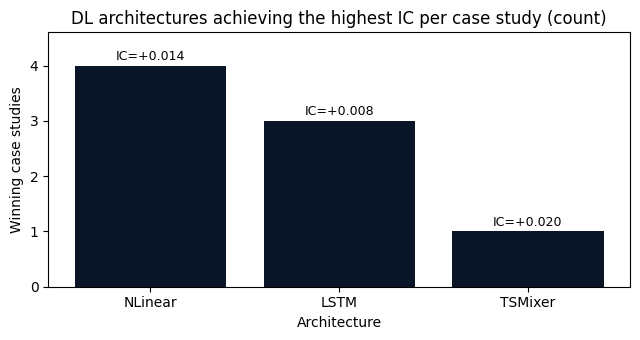

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(
    arch_top_counts["architecture"].to_list(),
    arch_top_counts["n_cs_with_highest_ic"].to_list(),
    color=COLORS["blue"],
)
ax.set_xlabel("Architecture")
ax.set_ylabel("Winning case studies")
ax.set_title("DL architectures achieving the highest IC per case study (count)")
ax.set_ylim(0, float(arch_top_counts["n_cs_with_highest_ic"].max()) + 0.6)
for i, (n, ic) in enumerate(
    zip(
        arch_top_counts["n_cs_with_highest_ic"].to_list(),
        arch_top_counts["ic_mean"].to_list(),
    )
):
    ax.text(i, n + 0.1, f"IC={ic:+.3f}", ha="center", fontsize=9)
fig.tight_layout()
fig.show()

In [19]:
architecture_count_text = ", ".join(
    f"{row['architecture']}: {row['n_cs_with_highest_ic']}"
    for row in arch_top_counts.iter_rows(named=True)
)
display(
    Markdown(
        f"**Computed architecture counts.** {architecture_count_text}. Counts describe the "
        "pinned point-estimate leaders; they do not establish superiority across panels."
    )
)

**Computed architecture counts.** NLinear: 4, LSTM: 3, TSMixer: 1. Counts describe the pinned point-estimate leaders; they do not establish superiority across panels.

### 3c. Checkpoint dynamics

For each case study's highest-IC DL configuration, the per-checkpoint
(epoch) IC trajectory is plotted with the IQR band across folds. Peaked
curves identify clear early-stopping value; flat curves indicate the
optimization landscape is benign across the budget.

In [20]:
checkpoint_folds = collect_complete_checkpoint_fold_trajectories(dl_rank1)
ckpt_df = (
    checkpoint_folds.group_by(["short_name", "config_name", "checkpoint_value"])
    .agg(
        ic_median=pl.col("ic").median(),
        ic_q25=pl.col("ic").quantile(0.25),
        ic_q75=pl.col("ic").quantile(0.75),
    )
    .filter(pl.col("checkpoint_value").is_not_null())
    .with_columns(
        architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8),
    )
    .sort(["short_name", "checkpoint_value"])
)

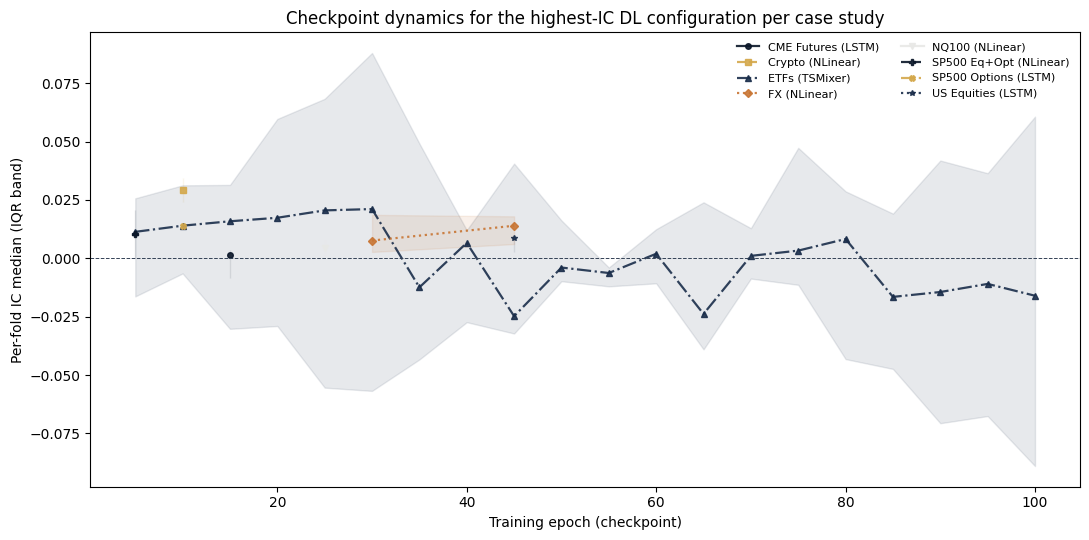

In [21]:
if not ckpt_df.is_empty():
    fig, ax = plt.subplots(figsize=(11, 5.5))
    palette = ml4t_palette(5, categorical=True)
    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    line_styles = ["-", "--", "-.", ":"]
    cs_sorted = sorted(ckpt_df["short_name"].unique().to_list())
    for i, cs in enumerate(cs_sorted):
        sub = ckpt_df.filter(pl.col("short_name") == cs).sort("checkpoint_value")
        x = sub["checkpoint_value"].to_numpy()
        med = sub["ic_median"].to_numpy()
        q25 = sub["ic_q25"].to_numpy()
        q75 = sub["ic_q75"].to_numpy()
        color = palette[i % len(palette)]
        arch = sub["architecture"].to_list()[0]
        ax.fill_between(x, q25, q75, color=color, alpha=0.10)
        ax.plot(
            x,
            med,
            color=color,
            marker=markers[i],
            linestyle=line_styles[i % len(line_styles)],
            label=f"{cs} ({arch})",
            linewidth=1.6,
            markersize=4,
            alpha=0.9,
        )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Training epoch (checkpoint)")
    ax.set_ylabel("Per-fold IC median (IQR band)")
    ax.set_title("Checkpoint dynamics for the highest-IC DL configuration per case study")
    ax.legend(loc="best", frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    fig.show()
else:
    print("No DL checkpoint data available.")

In [22]:
trajectory_peaks = (
    ckpt_df.sort("ic_median", descending=True)
    .group_by("short_name")
    .first()
    .select("short_name", "architecture", "checkpoint_value", "ic_median")
    .sort("checkpoint_value")
)
peak_text = ", ".join(
    f"{row['short_name']}: {int(row['checkpoint_value'])}"
    for row in trajectory_peaks.iter_rows(named=True)
)
display(Markdown(f"**Computed checkpoint peaks.** Selected median-IC peaks occur at {peak_text}."))

**Computed checkpoint peaks.** Selected median-IC peaks occur at SP500 Eq+Opt: 5, SP500 Options: 10, Crypto: 10, CME Futures: 15, NQ100: 25, ETFs: 30, FX: 45, US Equities: 45.

## 4. Stability and Uncertainty

Average daily IC with HAC CI is the headline metric. Per-fold IC is the
stability diagnostic; conformal coverage is the calibration diagnostic.

### 4a. Per-fold IC distribution

For each DL-covered case study, the per-fold IC distribution of the highest-
IC configuration is shown as a box-plus-scatter, sorted left-to-right by
headline IC.

In [23]:
dl_fold = collect_complete_fold_ic_per_cs(dl_rank1)
dl_fold_summary = (
    dl_fold.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC DL configuration (primary label):")
dl_fold_summary

Per-fold IC summary for the highest-IC DL configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""crypto_perps_funding""","""Crypto""",2,0.029333,0.007233,1.0
"""etfs""","""ETFs""",8,0.013988,0.032622,0.625
"""fx_pairs""","""FX""",8,0.013962,0.012856,0.875
"""sp500_options""","""SP500 Options""",2,0.013891,0.001798,1.0
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.010421,0.014804,0.5
"""us_equities_panel""","""US Equities""",16,0.008686,0.005072,0.8125
"""nasdaq100_microstructure""","""NQ100""",2,0.00456,0.004429,1.0
"""cme_futures""","""CME Futures""",5,0.001303,0.018793,0.6


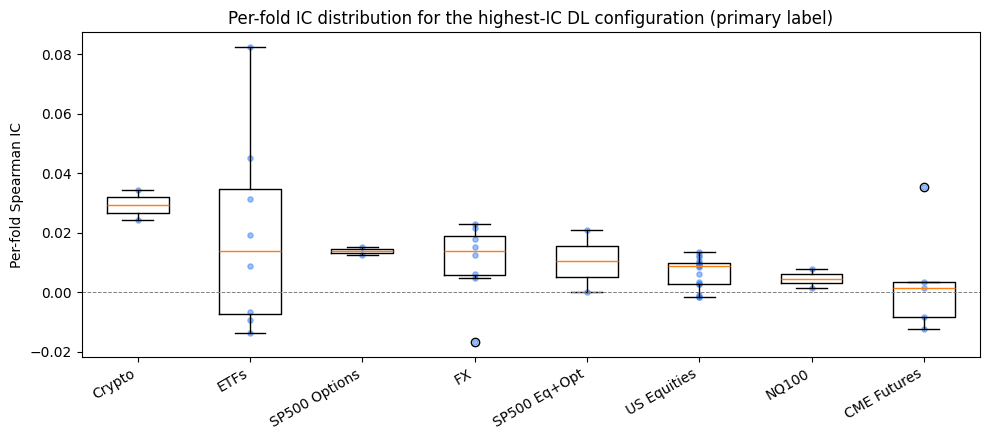

In [24]:
order = dl_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
fig, _ = plot_per_fold_violin(
    dl_fold,
    order=order,
    title="Per-fold IC distribution for the highest-IC DL configuration (primary label)",
)
fig.show()

Fold summaries diagnose stability only. Inference remains attached to the
chronological daily IC series, not to the small collection of fold summaries.

In [25]:
positive_majority = dl_fold_summary.filter(pl.col("pct_positive") > 0.5)["short_name"].to_list()
display(
    Markdown(
        f"**Computed fold diagnostic.** {len(positive_majority)} of "
        f"{dl_fold_summary.height} selected DL rows have a positive-fold majority: "
        f"{', '.join(positive_majority) or 'none'}."
    )
)

**Computed fold diagnostic.** 7 of 8 selected DL rows have a positive-fold majority: Crypto, ETFs, FX, SP500 Options, US Equities, NQ100, CME Futures.

### 4b. Cross-fitted OOF fold calibration at the 90 % nominal level

The oldest out-of-fold validation window calibrates a symmetric
absolute-residual quantile and the return scale. The diagnostic measures
empirical coverage on the later OOF windows at each nominal level. A
well-calibrated DL signal sits near the diagonal
(empirical coverage = nominal level); points below the diagonal indicate
the prediction interval is too narrow, points above indicate it is too
wide. Per-CS interval width is reported in calibration-window return
standard-deviation units. Because each OOF fold can come from a different
fitted model, this is a retrospective cross-fitted diagnostic, not a
same-model inductive split-conformal or operational coverage guarantee.

In [26]:
conformal_rows = []
for selected in dl_rank1.iter_rows(named=True):
    cs = selected["case_study"]
    df = conformal_coverage_for_selected_prediction(selected)
    sub = df.filter(pl.col("nominal_level") == CONFORMAL_LEVEL)
    if sub.is_empty():
        continue
    r = sub.row(0, named=True)
    conformal_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            "config_name": r["config_name"],
            "architecture": architecture(r["config_name"]),
            "nominal_level": r["nominal_level"],
            "empirical_coverage": r["empirical_coverage"],
            "interval_width_frac_std": r["mean_interval_width_frac_std"],
            "n_test": r["n_test"],
        }
    )

conformal_df = pl.DataFrame(conformal_rows).sort("short_name")
print(f"Cross-fitted OOF calibration at the {CONFORMAL_LEVEL:.0%} nominal level:")
conformal_df.select(
    "short_name",
    "architecture",
    pl.col("empirical_coverage").round(3).alias("empirical_cov"),
    pl.col("interval_width_frac_std").round(3).alias("width_frac_std"),
    "n_test",
)

Cross-fitted OOF calibration at the 90% nominal level:


short_name,architecture,empirical_cov,width_frac_std,n_test
str,str,f64,f64,i64
"""CME Futures""","""LSTM""",0.846,4.312,30702
"""Crypto""","""NLinear""",0.985,7.719,16600
"""ETFs""","""TSMixer""",0.892,3.662,166315
"""FX""","""NLinear""",0.76,3.965,36120
"""NQ100""","""NLinear""",1.0,459003.95,3261353
"""SP500 Eq+Opt""","""NLinear""",0.513,3.19,102360
"""SP500 Options""","""LSTM""",0.847,3.425,58533
"""US Equities""","""LSTM""",0.974,3.187,6589176


In [27]:
def staggered_offsets(values: np.ndarray, tolerance: float = 0.04) -> list[int]:
    offsets = [4] * len(values)
    last_value, last_offset = -np.inf, 4
    for index in sorted(range(len(values)), key=lambda i: values[i]):
        offsets[index] = last_offset + 12 if values[index] - last_value < tolerance else 4
        last_value, last_offset = values[index], offsets[index]
    return offsets

The complete calibration chart is assembled in one rendering cell. The
horizontal reference marks the nominal target, not a performance threshold.

In [28]:
def plot_conformal_coverage(conformal_df: pl.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7, 6))
    emp = conformal_df["empirical_coverage"].to_numpy()
    width = conformal_df["interval_width_frac_std"].to_numpy()
    names = conformal_df["short_name"].to_list()
    gap = np.abs(emp - CONFORMAL_LEVEL)
    cmap = LinearSegmentedColormap.from_list(
        "ml4t_calibration_gap", [COLORS["silver_muted"], COLORS["amber"]]
    )
    sc = ax.scatter(
        width,
        emp,
        s=90,
        edgecolor=COLORS["silver"],
        c=gap,
        cmap=cmap,
        vmin=0.0,
        vmax=max(0.01, float(gap.max())),
    )
    offsets = staggered_offsets(emp)
    for i, n in enumerate(names):
        ax.annotate(n, (width[i], emp[i]), textcoords="offset points", xytext=(7, offsets[i]))
    ax.axhline(
        CONFORMAL_LEVEL,
        color=COLORS["neutral"],
        linestyle="--",
        label=f"Nominal {CONFORMAL_LEVEL:.0%}",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Mean interval width (fraction of calibration-fold return std; log scale)")
    ax.set_ylabel("Empirical coverage")
    ax.set_title(f"Cross-fitted OOF calibration exposes scale drift at {CONFORMAL_LEVEL:.0%}")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.04, label="Absolute coverage gap")
    fig.tight_layout()
    return fig

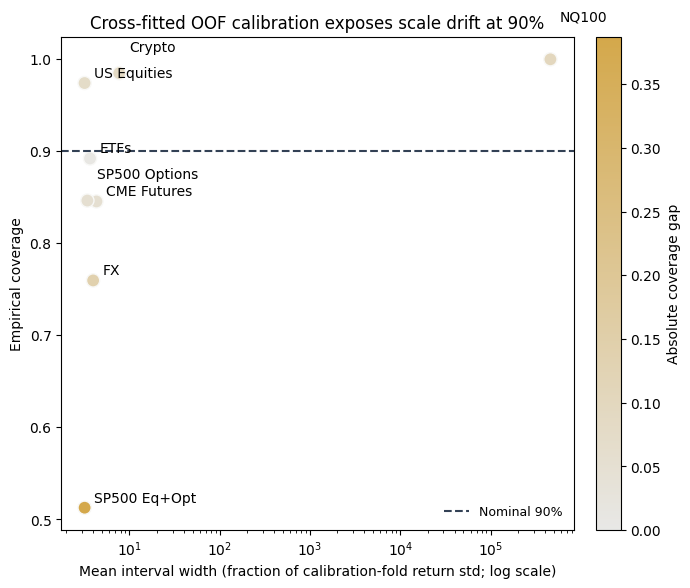

In [29]:
if not conformal_df.is_empty():
    fig = plot_conformal_coverage(conformal_df)
    fig.show()

In [30]:
if not conformal_df.is_empty():
    conformal_gap = conformal_df.with_columns(
        gap=(pl.col("empirical_coverage") - pl.col("nominal_level")).abs()
    ).sort("gap", descending=True)
    furthest = conformal_gap.row(0, named=True)
    nearest = conformal_gap.sort("gap").row(0, named=True)
    display(
        Markdown(
            f"**Computed conformal diagnostic.** The nearest panel to nominal is "
            f"{nearest['short_name']} ({nearest['empirical_coverage']:.3f}); the furthest is "
            f"{furthest['short_name']} ({furthest['empirical_coverage']:.3f}). The oldest OOF "
            "fold supplies calibration state and later OOF folds come from different fits, so "
            "this diagnostic is not a same-model conformal or operational coverage guarantee."
        )
    )

**Computed conformal diagnostic.** The nearest panel to nominal is ETFs (0.892); the furthest is SP500 Eq+Opt (0.513). The oldest OOF fold supplies calibration state and later OOF folds come from different fits, so this diagnostic is not a same-model conformal or operational coverage guarantee.

## 5. DL versus Tabular Baselines

The DL family enters a contested space - for every case study it is
compared to the highest-IC tabular configuration across linear, GBM, and
TabM. Two descriptive views compare full-coverage daily-IC point estimates.
Each family's chronological daily series retains its own HAC interval; the
notebook does not infer uncertainty from a small set of fold summaries.

In [31]:
def family_rank1_collect(family: str) -> pl.DataFrame:
    df = collect_complete_rank1_per_cs(
        CASE_STUDY_IDS,
        family=family,
        approved_registry_sha256=REGISTRY_SHA256_PINS,
        allow_missing=True,
    )
    if df.is_empty():
        return pl.DataFrame()
    return df.select(
        "case_study",
        "short_name",
        "config_name",
        "prediction_hash",
        "training_hash",
        "ic_n_days",
        pl.col("ic_mean_daily").alias(f"{family}_ic"),
    )

Apply the same complete-coverage selector to each tabular family before
choosing the strongest point estimate within a case study.

In [32]:
linear_rank1 = family_rank1_collect("linear")
gbm_rank1 = family_rank1_collect("gbm")
tabm_rank1 = family_rank1_collect("tabular_dl")

In [33]:
ic_lookup = {
    "linear": linear_rank1,
    "gbm": gbm_rank1,
    "tabular_dl": tabm_rank1,
}


def dl_tabular_delta(cs: str) -> dict | None:
    """Compare the selected DL row with the strongest tabular family row."""
    dl_row = dl_rank1.filter(pl.col("case_study") == cs)
    if dl_row.is_empty():
        return None
    selected_dl = dl_row.row(0, named=True)
    family_rows = {}
    for fam in TABULAR_BASELINES:
        sub = ic_lookup[fam].filter(pl.col("case_study") == cs)
        if not sub.is_empty():
            family_rows[fam] = sub.row(0, named=True)
    if not family_rows:
        return None
    best_fam = max(family_rows, key=lambda family: family_rows[family][f"{family}_ic"])
    best_row = family_rows[best_fam]
    best_baseline_ic = best_row[f"{best_fam}_ic"]
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "dl_arch": architecture(selected_dl["config_name"]),
        "dl_ic": selected_dl["ic_mean_daily"],
        "dl_prediction_hash": selected_dl["prediction_hash"],
        "dl_days": selected_dl["ic_n_days"],
        "best_baseline_family": best_fam,
        "best_baseline_ic": best_baseline_ic,
        "baseline_prediction_hash": best_row["prediction_hash"],
        "baseline_days": best_row["ic_n_days"],
        "delta": selected_dl["ic_mean_daily"] - best_baseline_ic,
    }

The comparison uses complete-coverage rows from each family and remains a
point-estimate diagnostic, not paired-fold inference.

In [34]:
delta_rows = [entry for cs in CASE_STUDY_IDS if (entry := dl_tabular_delta(cs)) is not None]

delta_df = pl.DataFrame(delta_rows).sort("delta", descending=True)
print("DL minus highest-IC full-coverage tabular baseline (descriptive, primary label):")
delta_df.select(
    "short_name",
    "dl_arch",
    "best_baseline_family",
    pl.col("dl_ic").round(4).alias("dl"),
    pl.col("best_baseline_ic").round(4).alias("base"),
    pl.col("delta").round(4),
    "dl_days",
    "baseline_days",
    "dl_prediction_hash",
    "baseline_prediction_hash",
)

DL minus highest-IC full-coverage tabular baseline (descriptive, primary label):


short_name,dl_arch,best_baseline_family,dl,base,delta,dl_days,baseline_days,dl_prediction_hash,baseline_prediction_hash
str,str,str,f64,f64,f64,f64,f64,str,str
"""Crypto""","""NLinear""","""gbm""",0.0293,0.011,0.0184,1956.0,1956.0,"""4d279db5157d""","""b1211734dc2d"""
"""SP500 Options""","""LSTM""","""gbm""",0.0138,0.0046,0.0092,484.0,484.0,"""159d481af175""","""55a90a2d2eb0"""
"""FX""","""NLinear""","""tabular_dl""",0.0106,0.0067,0.0039,2064.0,2064.0,"""49c6847ac96c""","""d3b951ceb349"""
"""NQ100""","""NLinear""","""gbm""",0.0046,0.006,-0.0014,64580.0,64580.0,"""4a2bcbc390e5""","""31cf1fc6f17b"""
"""SP500 Eq+Opt""","""NLinear""","""tabular_dl""",0.0105,0.0156,-0.0051,497.0,497.0,"""07841c23bf72""","""9a575854bf1e"""
"""CME Futures""","""LSTM""","""gbm""",0.004,0.0252,-0.0212,1290.0,1290.0,"""4c5c0a11b83e""","""feb32d10ca3f"""
"""US Equities""","""LSTM""","""gbm""",0.0066,0.0318,-0.0252,4018.0,4018.0,"""39ec35da4086""","""d3539f8398d1"""
"""ETFs""","""TSMixer""","""gbm""",0.0197,0.0513,-0.0316,2016.0,2016.0,"""14a299d42118""","""138b3de96269"""


### 5a. DL versus highest-IC tabular baseline - scatter

The scatter plots the highest-IC tabular baseline on the x-axis and the
highest-IC DL configuration on the y-axis, one point per case study.
Points above the diagonal indicate DL exceeds the highest-IC tabular
baseline; points below indicate the tabular baseline tops the DL signal.
Marker shape identifies the selected tabular family; color shows only the
direction of the point-estimate difference.

In [35]:
fam_marker = {"linear": "o", "gbm": "s", "tabular_dl": "D"}


def add_scatter_points(ax: plt.Axes, delta_df: pl.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    xs = delta_df["best_baseline_ic"].to_numpy()
    ys = delta_df["dl_ic"].to_numpy()
    rows = zip(
        xs,
        ys,
        delta_df["short_name"],
        delta_df["dl_arch"],
        delta_df["best_baseline_family"],
        strict=False,
    )
    for x, y, name, arch, family in rows:
        ax.scatter(
            x,
            y,
            s=90,
            marker=fam_marker[family],
            facecolor=COLORS["positive"] if y > x else COLORS["negative"],
            edgecolor=COLORS["blue"],
            linewidth=1.4,
        )
        ax.annotate(f"{name} ({arch})", (x, y), textcoords="offset points", xytext=(8, 4))
    return xs, ys

A common scale and equality line make the point-estimate comparison
interpretable without implying paired uncertainty.

In [36]:
def format_scatter_axes(ax: plt.Axes, xs: np.ndarray, ys: np.ndarray) -> None:
    lo = float(min(np.min(xs), np.min(ys))) - 0.005
    hi = float(max(np.max(xs), np.max(ys))) + 0.005
    ax.plot([lo, hi], [lo, hi], color=COLORS["neutral"], linestyle="--")
    ax.axhline(0, color=COLORS["silver_muted"], linewidth=0.5)
    ax.axvline(0, color=COLORS["silver_muted"], linewidth=0.5)
    ax.set_xlabel("Highest-IC tabular baseline (max of Linear, GBM, TabM)")
    ax.set_ylabel("Highest-IC DL configuration")
    ax.set_title("DL vs highest-IC tabular baseline at the primary label")

Shape identifies the selected tabular family; fill identifies only the
direction of the observed difference.

In [37]:
def scatter_legend_elements() -> list[Line2D]:
    family_labels = {"linear": "Linear", "gbm": "GBM", "tabular_dl": "TabM"}
    elements = [
        Line2D(
            [0],
            [0],
            marker=marker,
            color=COLORS["silver"],
            markerfacecolor=COLORS["silver_muted"],
            markeredgecolor=COLORS["blue"],
            markersize=9,
            label=f"Highest-IC tabular = {family_labels[family]}",
        )
        for family, marker in fam_marker.items()
    ]
    for color, label in [
        (COLORS["positive"], "DL point estimate > tabular"),
        (COLORS["negative"], "DL point estimate < tabular"),
    ]:
        elements.append(Line2D([0], [0], marker="o", color=color, label=label))
    elements.append(Line2D([0], [0], color=COLORS["neutral"], linestyle="--", label="DL = tabular"))
    return elements

The figure is created only after all drawing helpers are defined.

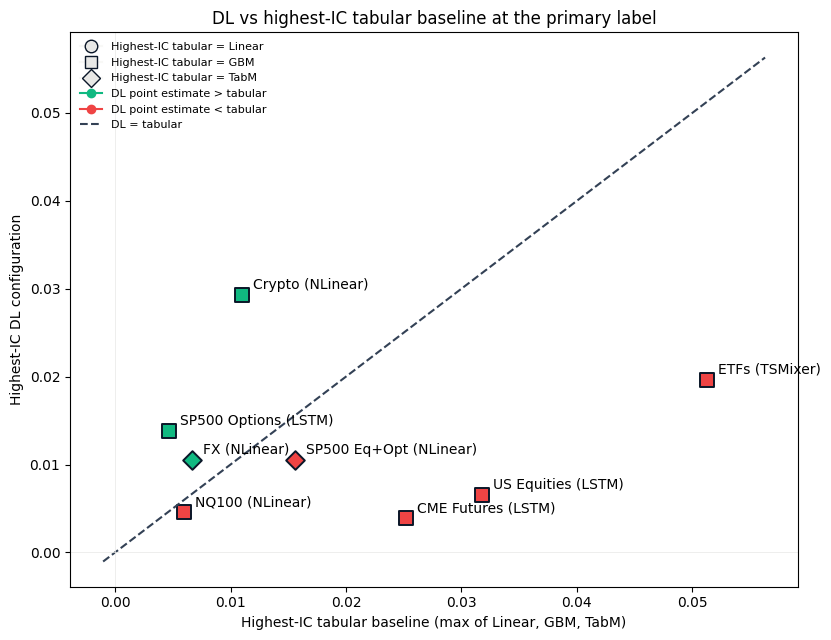

In [38]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
xs, ys = add_scatter_points(ax, delta_df)
format_scatter_axes(ax, xs, ys)
ax.legend(handles=scatter_legend_elements(), loc="upper left", frameon=False, fontsize=8)
fig.tight_layout()
fig.show()

In [39]:
n_above = int((ys > xs).sum())
print(
    f"DL > tabular point estimate on {n_above}/{len(ys)} case studies. "
    "No paired-fold inference is attached to this difference."
)

DL > tabular point estimate on 3/8 case studies. No paired-fold inference is attached to this difference.


### 5b. When does DL help? Diagnostic table

The same delta cross-referenced with panel-level features: data frequency,
universe size (entities), and the highest-IC tabular family. The rows are
sorted by the DL-minus-tabular point-estimate delta, largest first.

In [40]:
diagnostic_rows = []
for r in delta_df.iter_rows(named=True):
    cs = r["case_study"]
    meta = DATASET_META.get(cs, {})
    diagnostic_rows.append(
        {
            "short_name": r["short_name"],
            "frequency": meta.get("frequency"),
            "entities": meta.get("entities"),
            "best_tabular": r["best_baseline_family"],
            "tab_ic": r["best_baseline_ic"],
            "dl_arch": r["dl_arch"],
            "dl_ic": r["dl_ic"],
            "delta": r["delta"],
            "dl_days": r["dl_days"],
            "baseline_days": r["baseline_days"],
        }
    )

diagnostic_df = pl.DataFrame(diagnostic_rows)
print("DL-help diagnostic table (sorted by point-estimate delta, largest first):")
diagnostic_df.select(
    "short_name",
    "frequency",
    "entities",
    "best_tabular",
    "dl_arch",
    pl.col("tab_ic").round(4).alias("tab_ic"),
    pl.col("dl_ic").round(4).alias("dl_ic"),
    pl.col("delta").round(4).alias("delta"),
    "dl_days",
    "baseline_days",
)

DL-help diagnostic table (sorted by point-estimate delta, largest first):


short_name,frequency,entities,best_tabular,dl_arch,tab_ic,dl_ic,delta,dl_days,baseline_days
str,str,i64,str,str,f64,f64,f64,f64,f64
"""Crypto""","""8-hourly""",21,"""gbm""","""NLinear""",0.011,0.0293,0.0184,1956.0,1956.0
"""SP500 Options""","""Daily""",612,"""gbm""","""LSTM""",0.0046,0.0138,0.0092,484.0,484.0
"""FX""","""Daily""",20,"""tabular_dl""","""NLinear""",0.0067,0.0106,0.0039,2064.0,2064.0
"""NQ100""","""15-min""",114,"""gbm""","""NLinear""",0.006,0.0046,-0.0014,64580.0,64580.0
"""SP500 Eq+Opt""","""Daily""",638,"""tabular_dl""","""NLinear""",0.0156,0.0105,-0.0051,497.0,497.0
"""CME Futures""","""Daily""",30,"""gbm""","""LSTM""",0.0252,0.004,-0.0212,1290.0,1290.0
"""US Equities""","""Daily""",3199,"""gbm""","""LSTM""",0.0318,0.0066,-0.0252,4018.0,4018.0
"""ETFs""","""Daily""",99,"""gbm""","""TSMixer""",0.0513,0.0197,-0.0316,2016.0,2016.0


In [41]:
display(
    Markdown(
        f"**Computed baseline comparison.** DL has the higher full-coverage point estimate "
        f"in {n_above} of {delta_df.height} comparable case studies. The conclusion is "
        "descriptive until a daily-series difference estimator is registered and verified."
    )
)

**Computed baseline comparison.** DL has the higher full-coverage point estimate in 3 of 8 comparable case studies. The conclusion is descriptive until a daily-series difference estimator is registered and verified.

## 6. Multi-Label Horizon View

Only case studies with at least two complete registered regression labels
enter the horizon figure. Single-point series are excluded rather than
padded.

In [42]:
def regression_labels(cs: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[FAMILY])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None and (lbl.startswith("fwd_ret_") or lbl == "ret_to_expiry")
    ]

Only complete registered labels enter the horizon census and figure.

DL multi-label horizon coverage: 10 (CS, label) cells across 8 case studies.


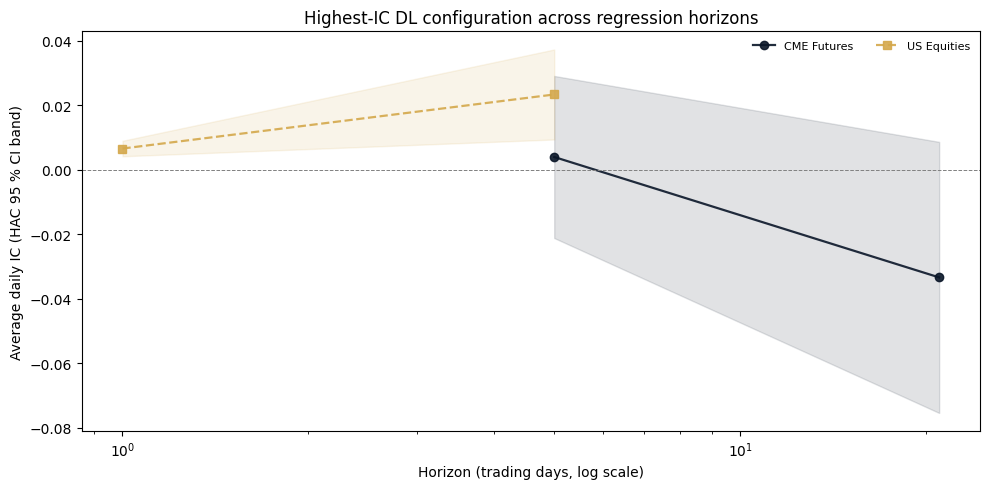

In [43]:
dl_horizon = collect_complete_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
    labels=regression_labels,
    approved_registry_sha256=REGISTRY_SHA256_PINS,
)
print(
    f"DL multi-label horizon coverage: {dl_horizon.height} (CS, label) cells "
    f"across {dl_horizon['case_study'].n_unique() if not dl_horizon.is_empty() else 0} case studies."
)

multi_horizon_cs = (
    dl_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
if multi_horizon_cs:
    fig, horizon_ax = plot_multi_label_horizon(
        dl_horizon,
        title="Highest-IC DL configuration across regression horizons",
    )
    horizon_ax.set_ylabel("Average daily IC (HAC 95 % CI band)")
    fig.show()
else:
    print(
        "No case study has ≥2 DL labels - horizon comparison is degenerate at the registry "
        "snapshot used here."
    )

In [44]:
display(
    Markdown(
        f"**Computed horizon coverage.** {len(multi_horizon_cs)} case studies have at least "
        f"two complete DL horizons ({', '.join(multi_horizon_cs) or 'none'}). Cross-panel horizon "
        "claims remain out of scope when the remaining panels have only one trained label."
    )
)

**Computed horizon coverage.** 2 case studies have at least two complete DL horizons (CME Futures, US Equities). Cross-panel horizon claims remain out of scope when the remaining panels have only one trained label.

## 7. Architectural Patterns

The five architectures map to four classes - recurrent (LSTM), MLP-style
(NLinear, TSMixer), convolutional (TCN), attention (PatchTST). For each
class, we read the highest IC achieved on each case study where the class
has at least one trained configuration.

In [45]:
def architecture_class_rows(cs: str) -> list[dict]:
    """Return highest-IC complete row for each trained architecture class."""
    df = dl_grid.filter(pl.col("case_study") == cs)
    if df.is_empty():
        return []
    df = (
        df.with_columns(
            architecture=pl.col("config_name").map_elements(architecture, return_dtype=pl.Utf8),
        )
        .with_columns(
            arch_class=pl.col("architecture").replace_strict(ARCH_CLASS, default=None),
        )
        .filter(pl.col("ic_mean_daily").is_not_null() & pl.col("arch_class").is_not_null())
    )
    if df.is_empty():
        return []
    by_class = (
        df.sort("ic_mean_daily", descending=True)
        .group_by("arch_class")
        .first()
        .select("arch_class", "ic_mean_daily", "ic_ci_lo", "ic_ci_hi", "ic_t_hac", "config_name")
    )
    return [{"short_name": SHORT_NAMES[cs], **r} for r in by_class.iter_rows(named=True)]

Missing architecture classes remain absent rather than being imputed.

In [46]:
class_rows = [row for cs in CASE_STUDY_IDS for row in architecture_class_rows(cs)]
class_df = pl.DataFrame(class_rows)
print("Highest IC per (case study × architecture class):")
class_df.sort(["short_name", "arch_class"]).select(
    "short_name",
    "arch_class",
    "config_name",
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
)

Highest IC per (case study × architecture class):


short_name,arch_class,config_name,ic,t_hac
str,str,str,f64,f64
"""CME Futures""","""MLP-style""","""nlinear""",-0.0084,-0.73
"""CME Futures""","""recurrent""","""lstm_h64""",0.004,0.31
"""Crypto""","""MLP-style""","""nlinear""",0.0293,4.58
"""Crypto""","""convolutional""","""tcn""",0.0024,0.37
"""Crypto""","""recurrent""","""lstm_h64""",0.0051,0.79
…,…,…,…,…
"""SP500 Eq+Opt""","""recurrent""","""lstm_h64""",0.01,1.26
"""SP500 Options""","""attention""","""patchtst""",0.009,1.57
"""SP500 Options""","""recurrent""","""lstm_h64""",0.0138,1.19


In [47]:
arch_classes = ["recurrent", "MLP-style", "convolutional", "attention"]
class_colors = {
    "recurrent": COLORS["blue"],
    "MLP-style": COLORS["amber"],
    "convolutional": COLORS["copper"],
    "attention": COLORS["positive"],
}

cs_order_class = sorted(class_df["short_name"].unique().to_list())
x = np.arange(len(cs_order_class))
width = 0.20


def add_architecture_bars(ax: plt.Axes) -> None:
    for i, cls in enumerate(arch_classes):
        sub = class_df.filter(pl.col("arch_class") == cls)
        ic, err_lo, err_hi = [], [], []
        for cs in cs_order_class:
            row = sub.filter(pl.col("short_name") == cs)
            if row.height == 0:
                ic.append(np.nan)
                err_lo.append(0.0)
                err_hi.append(0.0)
            else:
                r = row.row(0, named=True)
                ic.append(r["ic_mean_daily"])
                err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
                err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
        ax.bar(
            x + (i - 1.5) * width,
            np.array(ic, dtype=float),
            width=width,
            yerr=np.vstack([err_lo, err_hi]),
            capsize=2,
            color=class_colors[cls],
            label=cls,
        )

The HAC intervals belong to each selected daily IC series; they are not
uncertainty estimates for the difference between architecture classes.

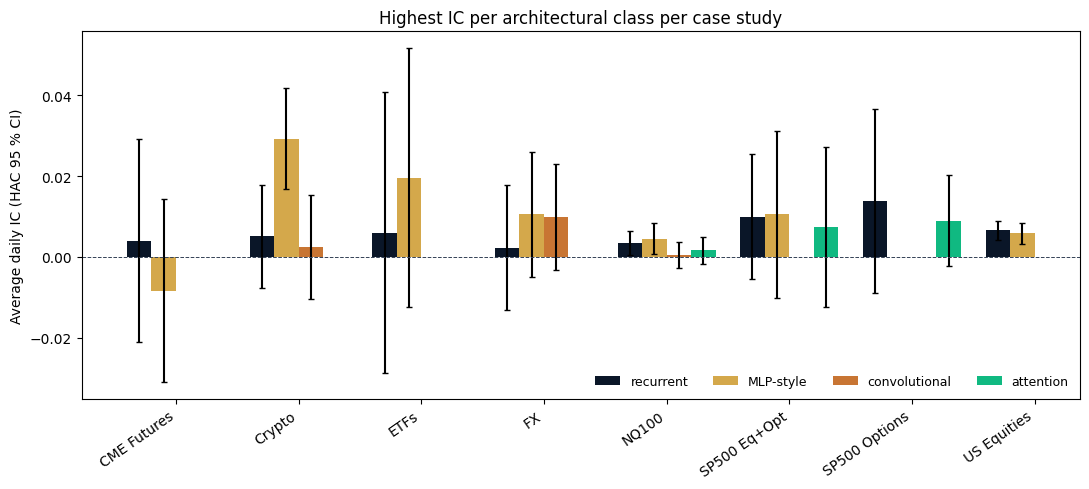

In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
add_architecture_bars(ax)
ax.set_xticks(x)
ax.set_xticklabels(cs_order_class, rotation=35, ha="right")
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_ylabel("Average daily IC (HAC 95 % CI)")
ax.set_title("Highest IC per architectural class per case study")
ax.legend(frameon=False, fontsize=9, loc="best", ncol=4)
fig.tight_layout()
fig.show()

In [49]:
class_top_per_cs = (
    class_df.sort("ic_mean_daily", descending=True)
    .group_by("short_name")
    .first()
    .group_by("arch_class")
    .agg(n_cs_with_highest_ic=pl.col("short_name").len())
    .sort("n_cs_with_highest_ic", descending=True)
)
print("Architectural class achieving the highest IC per case study (count):")
class_top_per_cs

Architectural class achieving the highest IC per case study (count):


arch_class,n_cs_with_highest_ic
str,u32
"""MLP-style""",5
"""recurrent""",3


In [50]:
class_count_text = ", ".join(
    f"{row['arch_class']}: {row['n_cs_with_highest_ic']}"
    for row in class_top_per_cs.iter_rows(named=True)
)
display(
    Markdown(
        f"**Computed architecture-class counts.** {class_count_text}. These are pinned "
        "point-estimate counts, not cross-case superiority estimates."
    )
)

**Computed architecture-class counts.** MLP-style: 5, recurrent: 3. These are pinned point-estimate counts, not cross-case superiority estimates.

## Cross-CS Key Takeaways

The synthesis below is computed from exact selected prediction hashes,
complete day/fold panels, and pinned registry identities.

In [51]:
largest_dl_delta = delta_df.row(0, named=True)
display(
    Markdown(
        "**Key takeaways**\n\n"
        f"- {dl_rank1.height} case studies have a complete primary-label DL candidate; "
        f"{len(dl_clear_names)} have HAC intervals that exclude zero.\n"
        f"- DL has the higher full-coverage point estimate in {n_above} of "
        f"{delta_df.height} comparisons with the strongest tabular family.\n"
        f"- The largest DL-minus-tabular point estimate is {largest_dl_delta['short_name']} "
        f"at {largest_dl_delta['delta']:+.4f}; the comparison remains descriptive without a "
        "registered daily paired-difference estimator.\n"
        "- NASDAQ-100 uses provisional snapshot status "
        f"`{REGISTRY_VERSION_STATUS['nasdaq100_microstructure']}` with "
        f"{REGISTRY_FOREIGN_KEY_DEBT.get('nasdaq100_microstructure', 0)} recorded foreign-key "
        "violations.\n\n"
        "**Next**: Ch14 adds latent-factor models on panels that satisfy the dimensionality "
        "gate; Ch15 layers causal effects on top of the predictive stack."
    )
)

**Key takeaways**

- 8 case studies have a complete primary-label DL candidate; 3 have HAC intervals that exclude zero.
- DL has the higher full-coverage point estimate in 3 of 8 comparisons with the strongest tabular family.
- The largest DL-minus-tabular point estimate is Crypto at +0.0184; the comparison remains descriptive without a registered daily paired-difference estimator.
- NASDAQ-100 uses provisional snapshot status `provisional_snapshot_20260722T182456` with 0 recorded foreign-key violations.

**Next**: Ch14 adds latent-factor models on panels that satisfy the dimensionality gate; Ch15 layers causal effects on top of the predictive stack.